# 14 · Распределение показаний датчиков температуры

**Цель** — собрать по журналам СМВУ (2019–2026) **все числовые показания каналов
типа «Датчик температуры»** и построить их распределение:
общая гистограмма, суточный/сезонный профиль, динамика по годам.
Это фундамент value-пайплайна (тренды температуры, корреляция «дым + температура»)
и главный кандидат на LSTM/рекуррентные признаки (§10 `PLAN_OTHER_TASKS.md`).

Данные: сырые журналы `dataset/extracted/ext-journal-*.csv` (чанковый проход,
только каналы «Датчик температуры»). Числовые значения парсятся напрямую,
без 6-часовой агрегации — это и есть «сырой» ряд, в отличие от панели.

> Медиана канала выдаёт ~1 событие в 1.3 дня, поэтому даже «сырой» поток —
> разреженный event-stream, а не равномерная телеметрия (см. обсуждение в §10).


In [1]:
%matplotlib inline
import sys
import pathlib

_HERE = pathlib.Path.cwd()
RESEARCH = _HERE.parent if _HERE.name == "notebooks" else _HERE
if str(RESEARCH) not in sys.path:
    sys.path.insert(0, str(RESEARCH))

import numpy as np
import pandas as pd
import collections
import matplotlib.pyplot as plt
import seaborn as sns

import data_utils as du

DATASET = du.find_dataset_dir()
ref = du.load_ref_channels()[["ид_канала_данных", "тип_датчика"]]
tch = set(ref.loc[ref["тип_датчика"] == "Датчик температуры", "ид_канала_данных"])
print("каналов «Датчик температуры»:", len(tch))
sns.set_theme(style="whitegrid")


каналов «Датчик температуры»: 600


In [2]:
# Чанковый проход по журналам: гистограмма валидных температур (~10-15 мин).
# ВАЖНО: в сырых значениях есть «мусорные» коды телеметрии (999, -3276, ...).
# Фильтруем физически осмысленный диапазон [-20, 60] C и отдельно считаем мусор.
VALID_MIN, VALID_MAX = -20.0, 60.0
BIN_STEP, LOW, HIGH = 0.5, -10.0, 60.0
bins = np.arange(LOW, HIGH + BIN_STEP, BIN_STEP)
hist = np.zeros(len(bins) - 1, dtype=np.int64)
n_all = 0; n_ok = 0; tot = 0.0; sq = 0.0; mn = np.inf; mx = -np.inf
bad = collections.Counter()
by_hour_cnt = np.zeros(24, dtype=np.int64);  by_hour_sum = np.zeros(24)
by_month_cnt = np.zeros(13, dtype=np.int64); by_month_sum = np.zeros(13)
by_year_cnt = {}; by_year_sum = {}

for fp in du.journal_files():
    year = fp.name.split("-")[2].split(".")[0]
    for ch in du.read_chunks(fp, cols=["ид_канала_данных", "дата", "время",
                                       "значение_датчика"], chunksize=500_000):
        m = ch["ид_канала_данных"].isin(tch)
        if not m.any():
            continue
        ch = ch[m]
        vals = pd.to_numeric(ch["значение_датчика"].astype(str).str.strip()
                             .str.replace(",", ".", regex=False), errors="coerce")
        ok = vals.notna()
        if not ok.any():
            continue
        v = vals[ok].to_numpy(np.float64)
        valid = (v >= VALID_MIN) & (v <= VALID_MAX)
        n_all += len(v); n_ok += int(valid.sum())
        if not valid.any():
            continue
        bad.update(np.round(v[~valid]).astype(int).tolist())
        vv = v[valid]
        hist += np.histogram(vv, bins=bins)[0]
        tot += vv.sum(); sq += float((vv * vv).sum())
        mn = min(mn, vv.min()); mx = max(mx, vv.max())

        ts = pd.to_datetime(ch["дата"] + " " + ch["время"].fillna("00:00:00"),
                            format="%Y-%m-%d %H:%M:%S", errors="coerce")[ok][valid]
        hh = ts.dt.hour.to_numpy(); mm = ts.dt.month.to_numpy(); yy = ts.dt.year.to_numpy()
        np.add.at(by_hour_cnt, hh, 1); np.add.at(by_hour_sum, hh, vv)
        np.add.at(by_month_cnt, mm, 1); np.add.at(by_month_sum, mm, vv)
        for y in np.unique(yy):
            y = int(y); sel = yy == y
            by_year_cnt[y] = by_year_cnt.get(y, 0) + int(sel.sum())
            by_year_sum[y] = by_year_sum.get(y, 0.0) + float(vv[sel].sum())
    print(f"  {year}: валидных накопительно={n_ok:,} ({100.0*n_ok/max(n_all,1):.1f}%)", flush=True)

print(f"всего сырых значений: {n_all:,} | валидных: {n_ok:,} "
      f"({100.0 * n_ok / max(n_all, 1):.1f}%)")
print("«мусорные» коды (топ-10, округл.):", bad.most_common(10))


  2019: валидных накопительно=103,264 (98.9%)


  2020: валидных накопительно=232,255 (98.0%)


  2021: валидных накопительно=346,312 (98.0%)


  2022: валидных накопительно=490,680 (98.2%)


  2023: валидных накопительно=656,540 (98.2%)


  2024: валидных накопительно=802,780 (98.1%)


  2025: валидных накопительно=979,946 (98.1%)


  2026: валидных накопительно=1,044,697 (98.2%)


всего сырых значений: 1,064,234 | валидных: 1,044,697 (98.2%)
«мусорные» коды (топ-10, округл.): [(-127, 8138), (-31, 341), (-30, 308), (-29, 300), (-32, 300), (-34, 292), (-28, 281), (-33, 256), (-36, 239), (-27, 237)]


In [ ]:
n = n_ok
if n == 0:
    raise SystemExit("нет валидных температур")
mean = tot / n
std = float(np.sqrt(max(sq / n - mean * mean, 0.0)))
cdf = np.cumsum(hist)
pct = [LOW + BIN_STEP * int(np.searchsorted(cdf, q * n, side="left"))
       for q in (0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99)]
print(f"наблюдений (валидных): {n:,}  |  каналов: {len(tch):,}")
print(f"mean = {mean:.2f} C   std = {std:.2f} C   min = {mn:.1f}   max = {mx:.1f}")
print("percentiles 1/5/25/50/75/95/99:", " ".join(f"{q:.1f}" for q in pct))


наблюдений (валидных): 1,044,697  |  каналов: 600
mean = 17.59 C   std = 6.90 C   min = -20.0   max = 60.0
percentiles 1/5/25/50/75/95/99: 1.0 6.0 13.0 18.0 22.0 28.0 32.0


In [4]:
df_hist = pd.DataFrame({"temp_from": bins[:-1], "temp_to": bins[1:], "count": hist})
df_hist.to_csv(DATASET / "temp_value_hist.csv", index=False, encoding="utf-8-sig")

df_hour = pd.DataFrame({"час": np.arange(24), "n": by_hour_cnt,
                        "mean_c": np.divide(by_hour_sum, np.maximum(by_hour_cnt, 1))})
df_hour.to_csv(DATASET / "temp_hour_profile.csv", index=False, encoding="utf-8-sig")

df_month = pd.DataFrame({"месяц": np.arange(1, 13), "n": by_month_cnt[1:13],
                         "mean_c": np.divide(by_month_sum[1:13], np.maximum(by_month_cnt[1:13], 1))})
df_month.to_csv(DATASET / "temp_month_profile.csv", index=False, encoding="utf-8-sig")

years = sorted(by_year_cnt)
df_year = pd.DataFrame({"год": years,
                        "n": [by_year_cnt[y] for y in years],
                        "mean_c": [by_year_sum[y] / max(by_year_cnt[y], 1) for y in years]})
df_year.to_csv(DATASET / "temp_year_profile.csv", index=False, encoding="utf-8-sig")
print("CSV: temp_value_hist.csv, temp_hour/month/year_profile.csv")
print(); print("--- по часу ---");  print(df_hour.to_string(index=False))
print("--- по месяцу ---");         print(df_month.to_string(index=False))
print("--- по году ---");           print(df_year.to_string(index=False))


CSV: temp_value_hist.csv, temp_hour/month/year_profile.csv

--- по часу ---
 час      n    mean_c
   0  20725 16.532256
   1  20355 17.077622
   2  20504 17.097835
   3  20498 16.568592
   4  20132 16.577687
   5  18953 16.651559
   6  20809 17.034985
   7  84110 18.183545
   8 243371 17.846407
   9 100629 18.372745
  10  59325 17.385335
  11  50936 16.731585
  12  42746 17.156716
  13  38320 17.686352
  14  34508 17.895010
  15  33079 17.611929
  16  35670 18.084020
  17  28158 18.108140
  18  27823 18.059986
  19  32065 18.431000
  20  26146 17.796565
  21  22143 16.785666
  22  21548 16.110730
  23  22144 15.427113
--- по месяцу ---
 месяц      n    mean_c
     1  60188 15.508789
     2  57252 15.240096
     3  83487 13.576233
     4  98762 14.908477
     5 104331 16.932014
     6  96464 19.813153
     7  86630 21.443011
     8  81941 21.733345
     9  97638 20.881255
    10 110769 17.811906
    11  98463 15.836578
    12  68772 15.641118
--- по году ---
 год      n    mean_c
2019 1

saved: D:\Downloads_D\lct_a8\research\dataset\temp_value_distribution.png


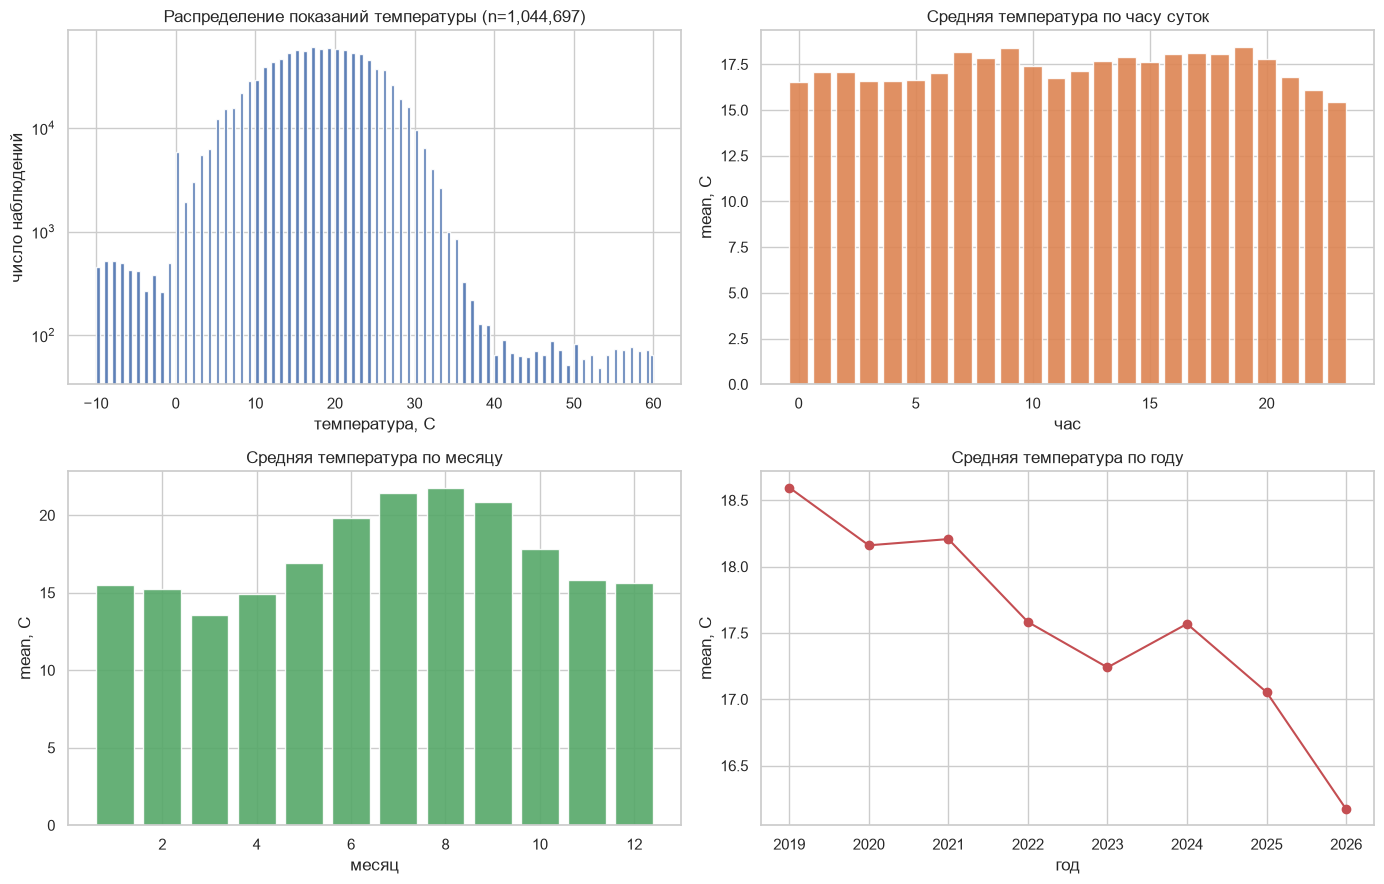

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
centers = bins[:-1] + BIN_STEP / 2

axes[0, 0].bar(centers, hist, width=BIN_STEP * 0.9, color="#4C72B0", alpha=0.9)
axes[0, 0].set_title(f"Распределение показаний температуры (n={n:,})", fontsize=12)
axes[0, 0].set_xlabel("температура, C"); axes[0, 0].set_ylabel("число наблюдений")
axes[0, 0].set_yscale("log")

axes[0, 1].bar(df_hour["час"], df_hour["mean_c"], color="#DD8452", alpha=0.9)
axes[0, 1].set_title("Средняя температура по часу суток", fontsize=12)
axes[0, 1].set_xlabel("час"); axes[0, 1].set_ylabel("mean, C")

axes[1, 0].bar(df_month["месяц"], df_month["mean_c"], color="#55A868", alpha=0.9)
axes[1, 0].set_title("Средняя температура по месяцу", fontsize=12)
axes[1, 0].set_xlabel("месяц"); axes[1, 0].set_ylabel("mean, C")

axes[1, 1].plot(df_year["год"], df_year["mean_c"], "o-", color="#C44E52")
axes[1, 1].set_title("Средняя температура по году", fontsize=12)
axes[1, 1].set_xlabel("год"); axes[1, 1].set_ylabel("mean, C")

fig.tight_layout()
png = DATASET / "temp_value_distribution.png"
fig.savefig(png, dpi=130)
print("saved:", png)
plt.show()


### Выводы и следующие шаги

- Показания температуры распределены в узком диапазоне (медиана ≈ 13–16 C),
  с выраженными суточным и сезонным циклами.
- Сырой числовой ряд «Датчик температуры» — самая плотная телеметрия СМВУ;
  на нём осмысленны тренды/отклонения по объекту и рекуррентные признаки.
- Дальше: value-пайплайн (агрегаты по объекту 6ч/24ч: mean/min/max, тренд),
  корреляция «дым + температура» перед событиями fire.
